In [1]:
from functions import *

In [21]:
# Date to start training. Testing will occur one year later over the course of one year.
start_date = '2020-12-01'
num_stocks = 2500
pct = 0.98
folder = 'compiled'
# If there is extended data, we can use more than one year
years = 1

model = XGBRegressor(max_depth=6, n_estimators=200, learning_rate=0.3)
model, predictions, values = train_and_predict(model, start_date, num_stocks, years, folder)
pct_values = return_pct(predictions, values, pct=pct)[0]
# pct_values = remove_outliers(pct_values)
# This actually isn't realistic as we wouldn't ever discard incredibly high returns.
# However, it can be nice for the sake of comparison between different years.
print(f"Model MAE: {mean_absolute_error(predictions, values)}")
print(f"Average return over 1 year: {np.average(pct_values)}")
print(f"Total number of stocks invested in: {len(pct_values)}")

num_correct = 0
for value in pct_values:
        if value >= 0.03556:
            num_correct += 1
print(f"Investment Grade Precision: {num_correct / len(pct_values)}")

Model MAE: 0.473323591617159
Average return over 1 year: 0.4032876349539135
Total number of stocks invested in: 49
Investment Grade Precision: 0.5510204081632653


<Axes: >

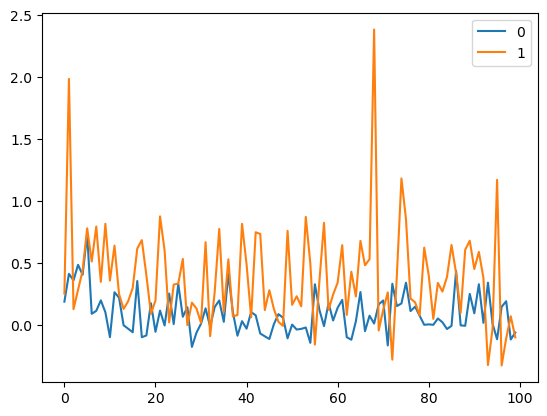

In [3]:
pd.concat([pd.Series(predictions), pd.Series(values)], axis=1)[:100].plot()

In [4]:
start_date = add_days(start_date, 365)
stock_df = predict(model, num_stocks, start_date, years, folder, pct=pct)
backtest(stock_df, start_date, years)

,Return,Date
0,1.000000,2023-12-01
1,1.042077,2023-12-02
2,1.042077,2023-12-03
3,1.042077,2023-12-04
4,1.030358,2023-12-05
...,...,...
361,2.984672,2024-11-26
362,3.041937,2024-11-27
363,3.028997,2024-11-28
364,3.028997,2024-11-29


In [5]:
stock_df

,Stock Ticker,Date,Return
0,MIRM,2023-12-01,0.449813
1,MDXG,2023-12-01,0.196382
2,SCS,2023-12-01,0.132863
3,TY,2023-12-01,0.290707
4,NAMS,2023-12-01,1.044103
5,FTF,2023-12-01,0.207530
6,DESP,2023-12-01,1.241855
7,EOS,2023-12-01,0.372090
8,RVT,2023-12-01,0.346085
9,NVAX,2023-12-01,0.596364


## Feature Importance

We can find the features most prominent in individual predictions and calculate feature importance in aggregate over the entire dataset

In [108]:
ticker = 'AAPL'
metric = 'marketCap'
pd.read_csv(f"data/compiled/{ticker}.csv", index_col=0).drop(['date', 'symbol', 'calendarYear', 'period'], axis=1)[start_date:].iloc[0][metric]

2695569789510.0

In [109]:
data = pd.read_csv(f"data/compiled/{ticker}.csv", index_col=0).drop(['date', 'symbol', 'calendarYear', 'period'], axis=1)
x = data[start_date:].iloc[0]
model.predict([x])

array([0.3297426], dtype=float32)

<Axes: >

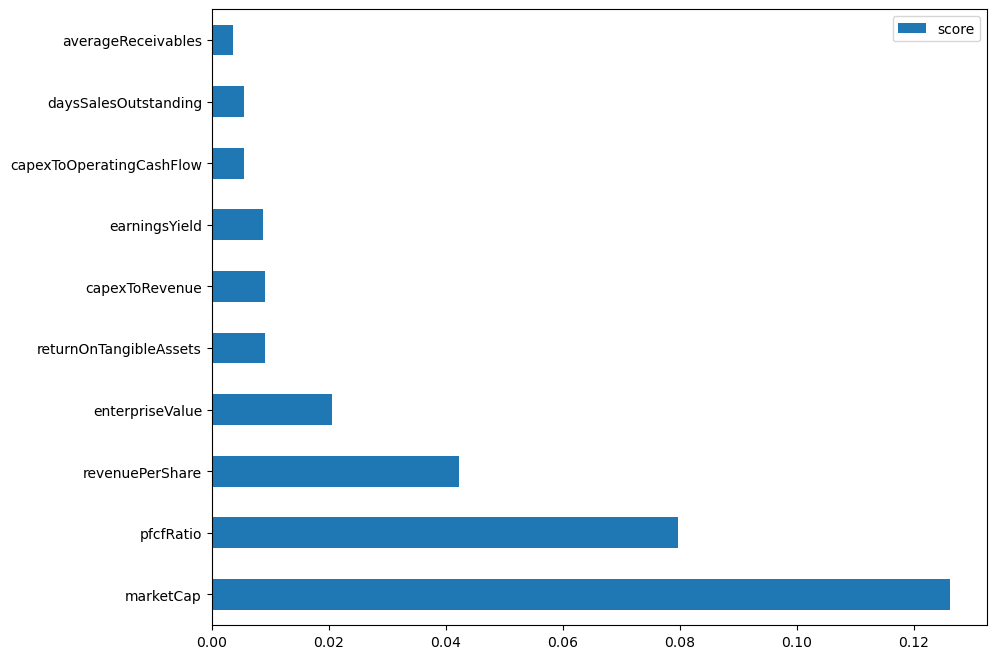

In [110]:
explainer = shap.Explainer(model)
shap_values = explainer([x])

# We can use a detailed graph that shows feature names and exact importance
num_values = len(shap_values[0])
values = [0] * num_values
for i in range(num_values):
    for j in range(len(shap_values)):
        values[i] += np.abs(shap_values.values[j][i] / len(shap_values))
        
keys = list(shap_values.data[0].index)
data = pd.DataFrame(data=values, index=keys, columns=["score"]).sort_values(by = "score", ascending=False)
data.nlargest(10, columns="score").plot(kind='barh', figsize = (10,8))

In [96]:
model2 = XGBRegressor(max_depth=7, n_estimators=1000, learning_rate=0.001)
model2, xlist = train(model, start_date, num_stocks, years, folder)

<Axes: >

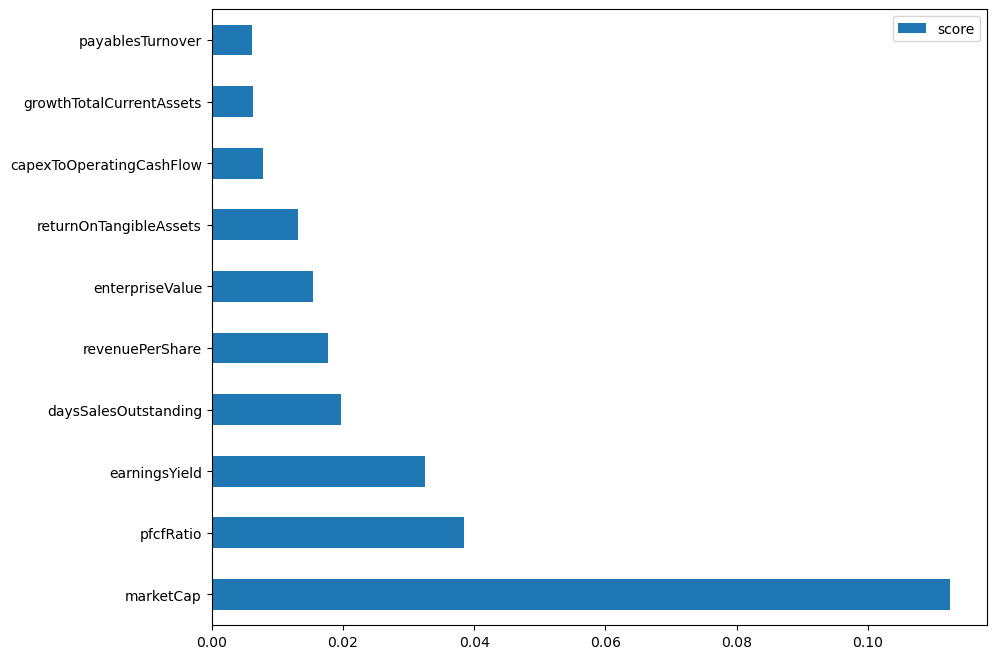

In [98]:
explainer = shap.Explainer(model)
shap_values = explainer(xlist)

# We can use a detailed graph that shows feature names and exact importance
num_values = len(shap_values[0])
values = [0] * num_values
for i in range(num_values):
    for j in range(len(shap_values)):
        values[i] += np.abs(shap_values.values[j][i] / len(shap_values))
        
keys = list(shap_values.data[0].index)
data = pd.DataFrame(data=values, index=keys, columns=["score"]).sort_values(by = "score", ascending=False)
data.nlargest(10, columns="score").plot(kind='barh', figsize = (10,8))

In [117]:
data = pd.read_csv(f"data/keymetrics/{ticker}.csv", index_col=0).drop(['date', 'symbol', 'calendarYear', 'period'], axis=1)
data['pfcfRatio']

fillingDate
2024-11-01    32.122569
2023-11-03    27.068302
2022-10-28    21.888924
2021-10-29    26.397759
2020-10-30    26.556204
Name: pfcfRatio, dtype: float64

TODO: train and test networks using a sliding window over the four years with different metric types and measure the classification accuracy of stocks picked (at or above 15% one-year return)

In [6]:
predict_final(model, num_stocks, "2025-01-01")

,Stock Ticker,Date
0,CRM,2025-01-01
1,APP,2025-01-01
2,NVO,2025-01-01
3,PLTR,2025-01-01
4,PTCAY,2025-01-01
